# 0. Подготовка


## Шаг 1. Импорты

In [775]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.multioutput import MultiOutputRegressor
import sklearn
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

## Шаг 2. Скачивание датасета


Перейдите по ссылке из личного кабинета на Google Таблицу со списком студентов. Найдите свое ФИО в списке и запомните соответствующий порядковый номер. Заполните его в ячейке ниже и выполните ячейку. Если вы не можете найти себя в списке, обратитесь к своему преподавателю.

In [ ]:
Student_ID = 333342

Теперь выполните следующую ячейку. Она вычислит номер задания и выведет его.

In [777]:
datasets = [
    (
        'Combined Cycle Power Plant',
        'https://archive.ics.uci.edu/dataset/294/combined+cycle+power+plant',
        'PE',
        85, 15
    ),
    (
        'Beijing PM2.5',
        'https://archive.ics.uci.edu/dataset/381/beijing+pm2+5+data',
        'pm2.5',
        80, 20
    ),
    (
        'Airfoil Self-Noise',
        'https://archive.ics.uci.edu/dataset/291/airfoil+self+noise',
        'scaled-sound-pressure',
        90, 10
    ),
    (
        'Energy Efficiency',
        'https://archive.ics.uci.edu/dataset/242/energy+efficiency',
        'Y1, Y2 (здесь две целевые переменные)',
        90, 10
    ),
    (
        'Bike Sharing',
        'https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset',
        'cnt',
        90, 10
    ),
    (
        'Forest Fires',
        'https://archive.ics.uci.edu/dataset/162/forest+fires',
        'area',
        90, 10
    ),
    (
        'Concrete Compressive Strength',
        'https://archive.ics.uci.edu/dataset/165/concrete+compressive+strength',
        'Concrete compressive strength',
        90, 10
    )
]

dataset_id = None if Student_ID is None else Student_ID % len(datasets)
if dataset_id is None:
    print("ОШИБКА! Не указан порядковый номер студента в списке группы.")
else:
    print(f"Информация о датасете '{datasets[dataset_id][0]}' доступна по следующей ссылке: {datasets[dataset_id][1]}")
    print(f"Целевая переменная: {datasets[dataset_id][2]}")
    print(f"Разделение выборки на train+val/test: {datasets[dataset_id][3]}%/{datasets[dataset_id][4]}%")

Информация о датасете 'Energy Efficiency' доступна по следующей ссылке: https://archive.ics.uci.edu/dataset/242/energy+efficiency
Целевая переменная: Y1, Y2 (здесь две целевые переменные)
Разделение выборки на train+val/test: 90%/10%


## Шаг 3. Загрузка и обработка датасета

Считайте датасет в датафрейм и обработайте его.

In [778]:
df = pd.read_csv('ENB2012_data.csv')
df = df.iloc[:, :-2]
df.head()

,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
0,0.98,514.5,294.0,110.25,7.0,2.0,0.0,0.0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3.0,0.0,0.0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4.0,0.0,0.0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5.0,0.0,0.0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2.0,0.0,0.0,20.84,28.28


В обработке датасета вы имеете (почти) полную свободу (важно в итоге просто побить бейзлайн).

Что НЕОБХОДИМО сделать:
- обработать пропуски, если есть
- закодировать категориальные фичи

Что ПОЛЕЗНО сделать:
- удалить дубликаты, если есть
- обработать выбросы
- удалить лишние фичи, если есть (возможно, полезно будет посмотреть на корреляции числовых признаков)
- стандартизировать данные, (выход модели необходимо будет привести к исходному масштабу, так что коэффициенты стандартизации нужно запомнить)

ПОДСКАЗКА: https://scikit-learn.org/stable/api/sklearn.preprocessing.html в помощь

ВАЖНО: обработанный по необходимым пунктам датафрейм запишите в переменную `df_base`, обработанный далее по вашему желанию датафрейм запишите в переменную `df_processed`.

НЕ ПЕРЕЗАПИСЫВАЙТЕ ЭТИ ПЕРЕМЕННЫЕ И `df`.

In [779]:
df_base = df.copy().dropna()
df_base.head()

,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
0,0.98,514.5,294.0,110.25,7.0,2.0,0.0,0.0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3.0,0.0,0.0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4.0,0.0,0.0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5.0,0.0,0.0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2.0,0.0,0.0,20.84,28.28


In [780]:
df_processed = df_base.copy().drop_duplicates()

features_to_scale, targets = ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8'], ['Y1', 'Y2']
for feature in features_to_scale:
    df_processed[feature] = (df_processed[feature] - df_processed[feature].mean()) / df_processed[feature].std()

df_processed.head()

,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
0,2.040447,-1.784712,-0.561586,-1.469119,0.999349,-1.340767,-1.7593,-1.813393,15.55,21.33
1,2.040447,-1.784712,-0.561586,-1.469119,0.999349,-0.446922,-1.7593,-1.813393,15.55,21.33
2,2.040447,-1.784712,-0.561586,-1.469119,0.999349,0.446922,-1.7593,-1.813393,15.55,21.33
3,2.040447,-1.784712,-0.561586,-1.469119,0.999349,1.340767,-1.7593,-1.813393,15.55,21.33
4,1.284142,-1.228438,0.000000,-1.197897,0.999349,-1.340767,-1.7593,-1.813393,20.84,28.28


# 1. Линейная регрессия с помощью sklearn

## Шаг 1. Разделение на train/val/test выборки

Разделите датафрейм на фичи и на целевую переменную (в одном из вариантов две целевых переменных)

In [781]:
X_base = df_base.drop(columns=['Y1', 'Y2'])
y_base = df_base[['Y1', 'Y2']]

X_processed = df_processed.drop(columns=['Y1', 'Y2'])
y_processed = df_processed[['Y1', 'Y2']]

Разделите датафреймы `base` и `processed` каждый на выборки train/val/test (запишите их в переменные ниже)

In [782]:
X_trainval_base, X_test_base, y_trainval_base, y_test_base = train_test_split(
    X_base,
    y_base,
    test_size=0.1,  # 10% на тест
    random_state=42,
    shuffle=True
)

X_train_base, X_val_base, y_train_base, y_val_base = train_test_split(
    X_trainval_base,
    y_trainval_base,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

In [783]:
X_trainval_processed, X_test_processed, y_trainval_processed, y_test_processed = train_test_split(
    X_processed,
    y_processed,
    test_size=0.1,  # 10% на тест
    random_state=42,
    shuffle=True
)

X_train_processed, X_val_processed, y_train_processed, y_val_processed = train_test_split(
    X_trainval_processed,
    y_trainval_processed,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

ВАЖНО: размер test-выборки указан в вашем варианте задания (рядом с ссылкой на скачивание датасета)

# Шаг 2. Обучение линейной регрессии

![линРег](im/linReg.png)

Обучите линейную регресию, используя scikit-learn библиотеку

In [784]:
def baseline():
  lin_reg = LinearRegression()
  lin_reg.fit(X_train_base, y_train_base)
  return lin_reg.predict(X_test_base)

y_pred_base = baseline()

Результат предсказания на тестовой выборке запишите в переменную `y_pred_processed`.

ЗАДАЧА: побить бейзлайн - получить итоговые метрики лучше, чем метрики для `y_pred_base`

ПОДСКАЗКА: вы можете настраивать гиперпараметры модели на валидационной выборке, на тестовой выборке вычисляются только конечные метрики

In [796]:
model = make_pipeline(
    PolynomialFeatures(degree=5),
    Ridge(alpha=1.0)
)

model.fit(X_train_processed, y_train_processed)
y_pred_processed = model.predict(X_test_processed)

![линРег](im/pipline.png)

In [797]:
print("MSE улучшенной модели:", mean_squared_error(y_test_processed, y_pred_processed))
print("MSE бейзлайн модели:", mean_squared_error(y_test_base, y_pred_base))

MSE улучшенной модели: 1.0346302914941192
MSE бейзлайн модели: 10.920475498875833


# 2. Реализация градиентного спуска с помощью numpy

В рамках этого задания реализуйте собственный стохастический градиентный спуск на numpy.

## Шаг 1. Реализация SGD


**1. Предсказание**
$
\hat{y} = XW + b
$


**2. Ошибка**
$
e = \hat{y} - y
$


**3. Функция потерь (MSE на батче)**
$
L_{\text{train}} = \frac{1}{m} \sum_{i=1}^{m} e_i^2
$

 **4. Градиент по весам**
$
\nabla_W L = \frac{2}{m} X^\top e
$

 **5. Градиент по смещению**
$
\nabla_b L = \frac{2}{m} \sum_{i=1}^{m} e_i
$

 **6. Обновление параметров**
$
W := W - lr \, \nabla_W L
$

$
b := b - lr \, \nabla_b L
$



**7. Предсказание на валидации**
$
\hat{y}_{val} = X_{val} W + b
$

 **8. Ошибка на валидации**
$
e_{val} = \hat{y}_{val} - y_{val}
$

 **9. Валидационная функция потерь**
$
L_{\text{val}} = \frac{1}{m_{val}} \sum_{i=1}^{m_{val}} e_{val,i}^2
$


In [787]:
class CustomSGD:
    def __init__(self, params, lr=0.01):
        self.params = params
        self.lr = lr
        self.train_losses = []
        self.val_losses = []

    def step(self, x_batch, y_batch, X_val=None, y_val=None):
        W, b = self.params
        X = np.asarray(x_batch, dtype=float)
        y = np.asarray(y_batch, dtype=float).reshape(-1, 1)

        W = np.asarray(W, dtype=float).reshape(-1, 1)
        b = np.asarray(b, dtype=float).reshape(1,)

        y_pred = X.dot(W) + b
        error = y_pred - y

        grad_W = (2 / len(X)) * X.T.dot(error)
        grad_b = (2 / len(X)) * np.sum(error)

        W = W - self.lr * grad_W
        b = b - self.lr * grad_b

        self.train_losses.append(np.mean(error ** 2))

        if X_val is not None and y_val is not None:
            X_val_arr = np.asarray(X_val, dtype=float)
            y_val_arr = np.asarray(y_val, dtype=float).reshape(-1, 1)
            y_val_pred = X_val_arr.dot(W) + b
            val_loss = np.mean((y_val_pred - y_val_arr) ** 2)
            self.val_losses.append(val_loss)

        self.params = [W, b]
        return self.params

# 3. Реализация линейной регрессии с помощью numpy

## Шаг 1. Реализация линейной регрессии

В рамках этого задания реализуйте класс собственной линейной регресии на numpy

In [788]:
class CustomLinearRegression:
    def __init__(self, lr=0.01, epochs=5):
        self.lr = lr
        self.epochs = epochs
        self.W = None
        self.b = None
        self.optimizer = None

    def fit(self, X, y, X_val=None, y_val=None):
        X = np.asarray(X)
        y = np.asarray(y).reshape(-1, 1)

        n_samples, n_features = X.shape

        self.W = np.zeros((n_features, 1))
        self.b = np.array([0.0])
        self.optimizer = CustomSGD([self.W, self.b], lr=self.lr)
        rng = np.random

        for epoch in range(self.epochs):
            perm = rng.permutation(n_samples)
            X_shuffled = X[perm]
            y_shuffled = y[perm]

            for i in range(n_samples):
                x_i = X_shuffled[i:i+1]
                y_i = y_shuffled[i:i+1]

                params = self.optimizer.step(x_i, y_i, X_val, y_val)
                self.W, self.b = params

    def predict(self, X):
        W = self.W
        b = self.b
        return X.dot(W) + b

    def fit_closed_form(self, X, y):
        X = np.hstack([X, np.ones((X.shape[0],1))])
        full, *_ = np.linalg.lstsq(X, y)
        self.W = full[:-1]   
        self.b = full[-1].reshape(1,) 
        

Вы можете изменить интерфейс класса под свою реализацию, если посчитаете нужным. Главное - чтобы все работало :)

## Шаг 2. Обучите `CustomLinearRegression` с помощью `CustomSGD`

Обучите вашу модель с помощью вашего же SGD. Результаты запишите в переменную `y_pred_custom`.
Сохраняйте лосс на каждом батче, после обучения - постройте графики функции потерь на тренировочной и валидационной выборках.

Вычислите метрику MSE на тестовой выборке, сравните с обучением с помощью sklearn.

In [789]:
# Y1
model_y1 = CustomLinearRegression(lr=0.01, epochs=10)
print("Y1")
model_y1.fit(X_train_processed, y_train_processed.iloc[:, 0].values,
             X_val_processed, y_val_processed.iloc[:, 0].values)

# Y2
model_y2 = CustomLinearRegression(lr=0.01, epochs=10)
print("Y2")
model_y2.fit(X_train_processed, y_train_processed.iloc[:, 1].values,
             X_val_processed, y_val_processed.iloc[:, 1].values)

y_pred_custom = np.column_stack([
    model_y1.predict(X_test_processed),
    model_y2.predict(X_test_processed)
])

print(f"\nMSE кастомной модели: {mean_squared_error(y_test_processed, y_pred_custom):.4f}")

Y1
Y2

MSE кастомной модели: 12.6751


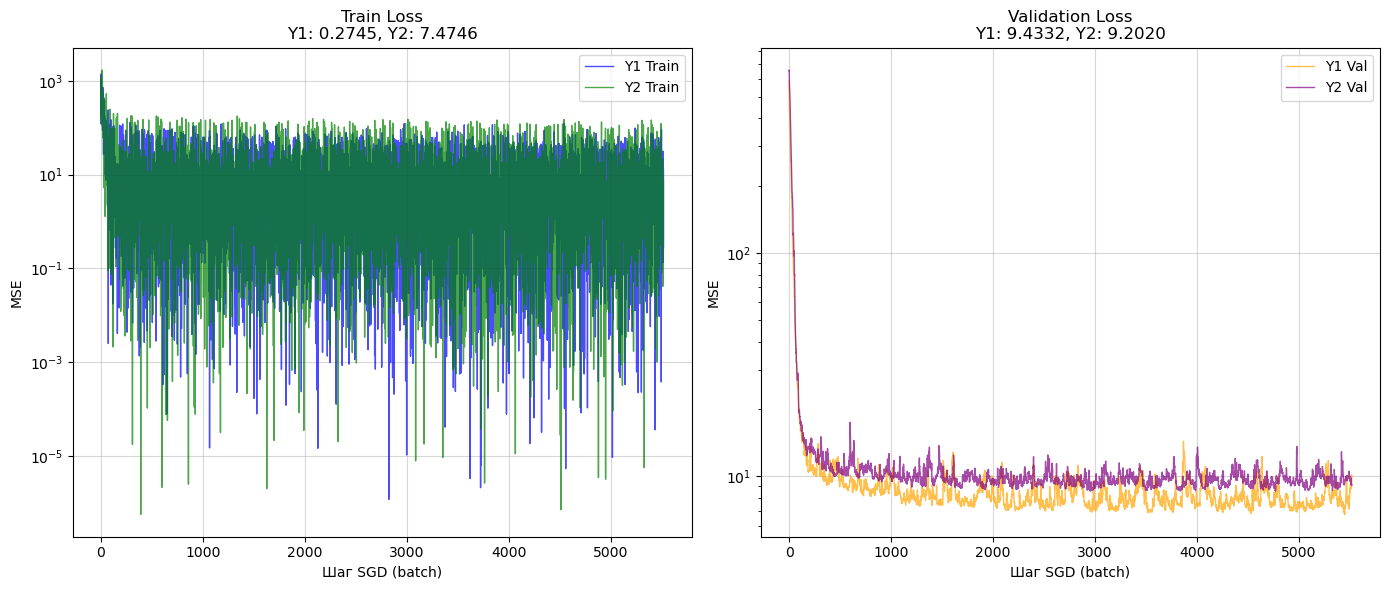

In [790]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Train Loss 
axes[0].plot(model_y1.optimizer.train_losses, alpha=0.7, linewidth=1, color='blue', label='Y1 Train')
axes[0].plot(model_y2.optimizer.train_losses, alpha=0.7, linewidth=1, color='green', label='Y2 Train')
axes[0].set_title(f'Train Loss\nY1: {model_y1.optimizer.train_losses[-1]:.4f}, Y2: {model_y2.optimizer.train_losses[-1]:.4f}')
axes[0].set_xlabel('Шаг SGD (batch)')
axes[0].set_ylabel('MSE')
axes[0].grid(True, alpha=0.5)
axes[0].legend()
axes[0].set_yscale('log')

# Validation Loss 
axes[1].plot(model_y1.optimizer.val_losses, alpha=0.7, linewidth=1, color='orange', label='Y1 Val')
axes[1].plot(model_y2.optimizer.val_losses, alpha=0.7, linewidth=1, color='purple', label='Y2 Val')
axes[1].set_title(f'Validation Loss\nY1: {model_y1.optimizer.val_losses[-1]:.4f}, Y2: {model_y2.optimizer.val_losses[-1]:.4f}')
axes[1].set_xlabel('Шаг SGD (batch)')
axes[1].set_ylabel('MSE')
axes[1].grid(True, alpha=0.5)
axes[1].legend()
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

## Шаг 2. Доп задание *
Обучите вашу линейную регрессию (CustomLinearRegression) с помощью метода наименьших квадратов на вашем датасете (если датасет слишком большой и colab не справляется - возьмите его долю).

In [791]:
model_y1 = CustomLinearRegression()
print("Y1 (OLS)")
model_y1.fit_closed_form(X_train_processed, y_train_processed.iloc[:, 0].values)

model_y2 = CustomLinearRegression()
print("Y2 (OLS)")
model_y2.fit_closed_form(X_train_processed, y_train_processed.iloc[:, 1].values)

pred1 = np.asarray(model_y1.predict(X_test_processed)).reshape(-1)  
pred2 = np.asarray(model_y2.predict(X_test_processed)).reshape(-1)  
y_pred_custom = np.column_stack([pred1, pred2]) 

print(f"\nMSE кастомной модели: {mean_squared_error(y_test_processed.values, y_pred_custom):.4f}")

Y1 (OLS)
Y2 (OLS)

MSE кастомной модели: 10.9205


# Вопросы к лабе с гитхаба

 #####  1. Ломает ли Feature-engineering над признаками (например, взятие логарифма от каждого элемента признака) "линейность" линейной регрессии?

- Модель остаётся линейной относительно параметров `w₁, w₂, ..., wₙ, b`, которые мы обучаем. Нелинейность вошла только в вычисление самих признаков до умножения на веса.

 #####  2. Как можно получить аналитическое решение линейной регрессии?

 - Если у нас 1 обьект: по формуле: $$ y' = w^T * x + b  \qquad\text{где:} $$



 $$ w = [w_1, w_2, w_3, ..., w_n] \qquad x = [x_1, x_2, x_3, ..., x_n] \qquad b - \text{смещение} $$

 - Если у  нас большой дасет:

1. Исходные данные
$ X ∈ R^{(m×n)} $ — матрица признаков  
$y ∈ R^m$ — вектор целевых значений  

2. Добавляем 
$X̃ = [1 | X]$ - добавляем столбец единиц  
$w̃ = [b; w]$ - вектор параметров (b - смещение)  

3. Модель
$ŷ = X̃*w̃$  

4. Функция потерь (MSE)
$L(w̃) = (1/m)‖X̃w̃ - y‖²$  

5. Минимизация
$∇L(w̃) = (2/m)X̃ᵀ(X̃w̃ - y) = 0$  

6. Нормальные уравнения
$X̃ᵀX̃w̃ = X̃ᵀy$  

7. Решение
$w̃ = (X̃ᵀX̃)⁻¹X̃ᵀy$ 

8. Результат
$b = w̃₀$ (первый элемент)  
$w = w̃₁₋ₙ$ (остальные — веса признаков)  


3. ##### Что такое bias-variance trade-off? Как выглядит bias-variance decomposition? Объяснить вкратце.
- `Bias-variance trade-off`- компромисс между смещением и разбросом

![линРег](im/bv.png)

![линРег](im/bvd.png)

##### 4. Что такое переобучение (overfitting) и недообучение (underfitting)? Какие стратегии борьбы с ними существуют?

- Переобучение (Overfitting) и недообучение (Underfitting) - описывают, насколько хорошо модель обобщает знания с обучающих данных на новые, невиданные ранее данные

- Способы борьбы: менять регулризацию (увеличить - переобучение будет норм) (рег - то, как модель воспринимает признаки(можно на шум забить)), также можно откинуть ненужные признаки

##### 5. Почему стохастический градиентный спуск способен сойтись? Какие есть преимущества и недостатки SGD по сравнению с обычным градиентным спуском? Как можно улучить SGD (смотри Momentum, RMSProp, Adam)?

1. сходимость
- адаптивный `lr`
- при помощи рандома уходит из лок минимумов
- делает шаг не на всех данных, а на точке данных

2. Отличия

Преимущества:
- обычный - много памяти, так как требует всю выборку, стох - меньше памяти, тк обучается на 1 батче
- стох может выпрыгуть из лок минов, обычный застрянет

Недостатки:
- сходится скачками
- 

3. Улучшения
- Momentum - Добавляем инерцию — градиент накапливается с предыдущих шагов
- Нестеров - Моментум + смотрим вперед (где буду после применения momentum)

# Доп задание **. Реализация Adam

В рамках этого доп задания реализуйте оптимизатор Adam и обучите `CustomLinearRegression` с его помощью.

In [792]:
class CustomAdam:
  def __init__(self):
    pass

  def step(self, params, x_batch, y_batch):
    pass

Также как и в задании 3, обучите `CustomLinearRegression` с помощью `CustomAdam`

In [793]:
# y_pred_adam = ...